2025-02-10 14:57:41,009 - INFO - Loading spectral data...
2025-02-10 14:57:41,011 - INFO - Processing XYZ data...
2025-02-10 14:57:41,011 - INFO - Normalizing data...
2025-02-10 14:57:41,013 - INFO - Training the model...
2025-02-10 14:57:41,015 - INFO - Epoch 1/300 - MSE Loss: 0.27465522289276123
2025-02-10 14:57:41,016 - INFO - Epoch 2/300 - MSE Loss: 0.25009796023368835
2025-02-10 14:57:41,018 - INFO - Epoch 3/300 - MSE Loss: 0.22631172835826874
2025-02-10 14:57:41,019 - INFO - Epoch 4/300 - MSE Loss: 0.10872361063957214
2025-02-10 14:57:41,021 - INFO - Epoch 5/300 - MSE Loss: 0.05014772340655327
2025-02-10 14:57:41,022 - INFO - Epoch 6/300 - MSE Loss: 0.0337674617767334
2025-02-10 14:57:41,024 - INFO - Epoch 7/300 - MSE Loss: 0.0499226413667202
2025-02-10 14:57:41,025 - INFO - Epoch 8/300 - MSE Loss: 0.032034192234277725
2025-02-10 14:57:41,026 - INFO - Epoch 9/300 - MSE Loss: 0.024249238893389702
2025-02-10 14:57:41,028 - INFO - Epoch 10/300 - MSE Loss: 0.025030085816979408
2025-0

Mean ΔE2000 Error: 6.560893051740086
Max ΔE2000 Error: 18.612387472582338


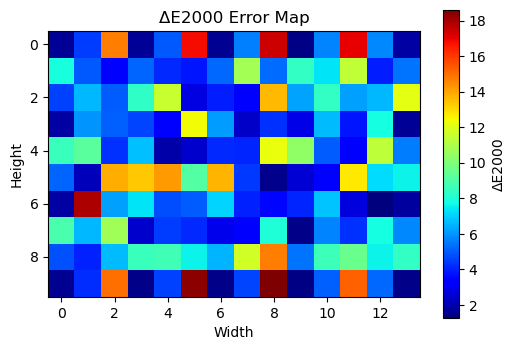

In [35]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_xyz(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to XYZ.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    return xyz

def xyz2lab(xyz):
    """Converts XYZ to Lab color space."""
    return color.xyz2lab(xyz)

def deltaE2000_loss(y_true, y_pred):
    """
    Computes the ΔE2000 color difference.
    """
    # Convert tensors to numpy arrays
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()
    
    # Convert XYZ to Lab
    lab_true = xyz2lab(y_true_np)
    lab_pred = xyz2lab(y_pred_np)
    
    # Compute ΔE2000
    delta_e2000 = color.deltaE2000(lab_true, lab_pred)
    
    # Return the mean ΔE2000
    return np.mean(delta_e2000)

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process XYZ data
###########################################
logging.info('Processing XYZ data...')
xyz_input = process_xyz(cube_data, wl_input, ill, CMFs)   
xyz_ref   = process_xyz(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data
###########################################
logging.info('Normalizing data...')
xyz_input_2d = xyz_input.reshape(-1, xyz_input.shape[-1])
xyz_ref_2d   = xyz_ref.reshape(-1, xyz_ref.shape[-1])

scaler_input = MinMaxScaler()
scaler_ref = MinMaxScaler()
X_norm = scaler_input.fit_transform(xyz_input_2d)
Y_norm = scaler_ref.fit_transform(xyz_ref_2d)

X_full = X_norm.reshape(xyz_input.shape)
Y_full = Y_norm.reshape(xyz_ref.shape)

###########################################
# 4. Prepare training data
###########################################
X_flat = X_full.reshape(-1, 3)
Y_flat = Y_full.reshape(-1, 3)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
X_train_split = X_flat[:train_size]
X_test_split  = X_flat[train_size:]
Y_train_split = Y_flat[:train_size]
Y_test_split  = Y_flat[train_size:]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define a simple MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

model = SimpleMLP(input_size=3, hidden_size=128, output_size=3)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

###########################################
# 6. Training loop (using MSE loss)
###########################################
epochs = 300
batch_size = 32

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
    
    logging.info(f'Epoch {epoch+1}/{epochs} - MSE Loss: {loss.item()}')

###########################################
# 7. Apply correction and evaluate with ΔE2000
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_xyz = scaler_ref.inverse_transform(corrected_flat)
corrected_xyz_image = corrected_xyz.reshape(xyz_ref.shape)

# Compute Lab images
lab_ref = xyz2lab(xyz_ref)
lab_corr = xyz2lab(corrected_xyz_image)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, lab_corr)

# Compute mean ΔE2000 error
mean_error = np.mean(error_map)
max_error = np.max(error_map)
logging.info(f"Mean ΔE2000 Error on test set: {mean_error}")
print("Mean ΔE2000 Error:", mean_error)
print("Max ΔE2000 Error:", max_error)


# Plot the ΔE2000 error map
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.title('ΔE2000 Error Map')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()


In [8]:
X_train.shape

(10, 14, 3)